# Benchmarking Memory-Efficient Fluorescence Quantification with Tiling

This tutorial demonstrates how to quantify fluorescence signals from very large microscopy images using a memory-efficient tiling approach.

Modern spatial transcriptomics platforms can generate extremely large fluorescence images. Loading these entire images into memory for quantification can cause memory errors on systems with limited resources. In `InSituData`'s `quantify_signal` function this can be an issue. Therefore, we implemented also a memory-efficient version of the algorithm, which consists of following steps:

1. **Splits** the large image into smaller, overlapping tiles
2. **Processes** each tile independently (lower memory footprint)
3. **Summarizes** results by selecting measurements corresponding to complete cells.

Here, we will benchmark the tiles approach against the standard method to demonstrate the trade-off between memory reduction and runtime performance.

In [1]:
## Ensure all functions are reloaded before execution
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, CACHE

c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load Data

First, load your InSituPy dataset with fluorescence images.

In [3]:
# Read the InSituPy project
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)

# Load required modalities
xd.load_images()
xd.load_cells()
xd.load_annotations()

In [4]:
# Extract image and mask for benchmarking
img = xd.images["CD20"][0]
mask = xd.cells.boundaries["cells"][0]

print(f"Image shape: {img.shape}")
print(f"Number of cells: {len(xd.cells.matrix.obs)}")

Image shape: (25778, 35416)
Number of cells: 156447


## Step 2: Import Benchmarking Functions

These functions will run both tiled and non-tiled quantification and compare their performance.

In [5]:
import numpy as np
import time
import tracemalloc
import matplotlib.pyplot as plt
from insitupy.utils._calc import create_tiles, quantify_fluorescence, summarize_tile_measurements


def benchmark_single_config(img, mask_zarr, tile_size=None, overlap=400):
    """
    Benchmark a single configuration (tiled or non-tiled).

    Parameters
    ----------
    img : dask array
        Fluorescence image
    mask_zarr : dask array
        Segmentation mask
    tile_size : int or None
        Tile size in pixels. If None, runs non-tiled approach
    overlap : int
        Overlap between tiles in pixels

    Returns
    -------
    result : dict
        Dictionary containing timing, memory, and measurement results
    """
    tracemalloc.start()
    start_time = time.time()

    if tile_size is None:
        # Non-tiled approach
        measurements, cell_ids = quantify_fluorescence(
            image_dask=img,
            mask_dask=mask_zarr,
            method="median",
            return_area=False
        )
        n_tiles = 1
    else:
        # Tiled approach
        img_tiles = create_tiles(img, tile_size=tile_size, overlap=overlap)
        mask_tiles = create_tiles(mask_zarr, tile_size=tile_size, overlap=overlap)

        quant_results = []
        for i in range(len(img_tiles)):
            img_tile = img_tiles[i][0]
            mask_tile = mask_tiles[i][0]
            quant_results.append(quantify_fluorescence(
                image_dask=img_tile,
                mask_dask=mask_tile,
                method="median",
                return_area=True
            ))

        measurements, cell_ids = summarize_tile_measurements(quant_results)
        n_tiles = len(img_tiles)

    elapsed = time.time() - start_time
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        'time': elapsed,
        'peak_memory_mb': peak_mem / 1024**2,
        'n_tiles': n_tiles,
        'n_cells': len(cell_ids),
        'measurements': measurements,
        'cell_ids': cell_ids
    }


def benchmark_quantification(img, mask_zarr, tile_sizes=[2000, 4000, 8000, 16000], overlap=400):
    """
    Benchmark tiled vs non-tiled fluorescence quantification across multiple tile sizes.

    Parameters
    ----------
    img : dask array
        Fluorescence image
    mask_zarr : dask array
        Segmentation mask
    tile_sizes : list of int
        Tile sizes to test in pixels
    overlap : int
        Overlap between tiles in pixels

    Returns
    -------
    results : dict
        Dictionary containing benchmark results for all configurations
    """
    results = {'configs': []}

    # Non-tiled approach
    print("Running non-tiled quantification...")
    result_full = benchmark_single_config(img, mask_zarr, tile_size=None, overlap=overlap)
    results['non_tiled'] = result_full

    print(f"  Time: {result_full['time']:.2f} s")
    print(f"  Peak memory: {result_full['peak_memory_mb']:.1f} MB")
    print(f"  Cells: {result_full['n_cells']}")

    # Sort for comparison
    sort_idx_full = np.argsort(result_full['cell_ids'])
    measurements_full_sorted = result_full['measurements'][sort_idx_full]
    cell_ids_full_sorted = result_full['cell_ids'][sort_idx_full]

    # Tiled approaches with different tile sizes
    for tile_size in tile_sizes:
        print(f"\nRunning tiled quantification (tile_size={tile_size}, overlap={overlap})...")
        result_tiled = benchmark_single_config(img, mask_zarr, tile_size=tile_size, overlap=overlap)

        print(f"  Time: {result_tiled['time']:.2f} s")
        print(f"  Peak memory: {result_tiled['peak_memory_mb']:.1f} MB")
        print(f"  Tiles: {result_tiled['n_tiles']}")
        print(f"  Cells: {result_tiled['n_cells']}")

        # Validation
        sort_idx_tiled = np.argsort(result_tiled['cell_ids'])
        measurements_tiled_sorted = result_tiled['measurements'][sort_idx_tiled]
        cell_ids_tiled_sorted = result_tiled['cell_ids'][sort_idx_tiled]

        ids_match = np.array_equal(cell_ids_full_sorted, cell_ids_tiled_sorted)
        measurements_match = np.array_equal(measurements_full_sorted, measurements_tiled_sorted)

        validation = {
            'ids_match': ids_match,
            'measurements_match': measurements_match
        }

        if not measurements_match:
            diff_mask = measurements_full_sorted != measurements_tiled_sorted
            n_diff = np.sum(diff_mask)
            validation['n_differences'] = n_diff
            validation['pct_differences'] = 100 * n_diff / len(cell_ids_full_sorted)
            print(f"  Differences: {n_diff} ({validation['pct_differences']:.2f}%)")
        else:
            print(f"  Validation: Perfect match")

        results['configs'].append({
            'tile_size': tile_size,
            'result': result_tiled,
            'validation': validation,
            'measurements_sorted': measurements_tiled_sorted
        })

    results['measurements_full_sorted'] = measurements_full_sorted
    results['cell_ids_sorted'] = cell_ids_full_sorted
    results['overlap'] = overlap

    return results


def plot_benchmark_results(results, save_path=None):
    """
    Create publication-ready plots of benchmark results.

    Parameters
    ----------
    results : dict
        Results dictionary from benchmark_quantification
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    """
    n_configs = len(results['configs'])
    fig = plt.figure(figsize=(14, 4))

    # Create gridspec for custom layout
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.3)

    # Extract data
    tile_sizes = [cfg['tile_size'] for cfg in results['configs']]
    times = [cfg['result']['time'] for cfg in results['configs']]
    memories = [cfg['result']['peak_memory_mb'] for cfg in results['configs']]
    n_tiles = [cfg['result']['n_tiles'] for cfg in results['configs']]

    time_full = results['non_tiled']['time']
    memory_full = results['non_tiled']['peak_memory_mb']

    # Plot 1: Time comparison
    ax1 = fig.add_subplot(gs[0])

    # Non-tiled baseline
    ax1.axhline(y=time_full, color='gray', linestyle='--', linewidth=1.5,
                label='Non-tiled', zorder=1)

    # Tiled results
    ax1.plot(tile_sizes, times, 'o-', color='#2E86AB', linewidth=2,
             markersize=8, label='Tiled', zorder=2)

    ax1.set_xlabel('Tile size (pixels)', fontsize=11)
    ax1.set_ylabel('Time (s)', fontsize=11)
    ax1.set_title('Runtime', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(axis='y', alpha=0.3)

    # Plot 2: Memory comparison
    ax2 = fig.add_subplot(gs[1])

    # Non-tiled baseline
    ax2.axhline(y=memory_full, color='gray', linestyle='--', linewidth=1.5,
                label='Non-tiled', zorder=1)

    # Tiled results
    ax2.plot(tile_sizes, memories, 'o-', color='#A23B72', linewidth=2,
             markersize=8, label='Tiled', zorder=2)

    ax2.set_xlabel('Tile size (pixels)', fontsize=11)
    ax2.set_ylabel('Peak memory (MB)', fontsize=11)
    ax2.set_title('Memory usage', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='y', alpha=0.3)

    # Add memory reduction annotation
    max_reduction = 100 * (1 - min(memories) / memory_full)
    ax2.text(0.5, 0.95, f'Max reduction: {max_reduction:.0f}%',
            transform=ax2.transAxes, ha='center', va='top',
            fontsize=9, style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Plot 3: Measurement validation for all tile sizes
    ax3 = fig.add_subplot(gs[2])

    colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_configs))

    measurements_full = results['measurements_full_sorted']

    for i, cfg in enumerate(results['configs']):
        measurements_tiled = cfg['measurements_sorted']
        label = f"{cfg['tile_size']}px ({cfg['result']['n_tiles']} tiles)"

        ax3.scatter(measurements_full, measurements_tiled,
                   s=1, alpha=0.3, color=colors[i], label=label, rasterized=True)

    # Add diagonal line
    min_val = measurements_full.min()
    max_val = measurements_full.max()
    ax3.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1, alpha=0.5, label='Identity')

    ax3.set_xlabel('Non-tiled measurement', fontsize=11)
    ax3.set_ylabel('Tiled measurement', fontsize=11)
    ax3.set_title('Measurement validation', fontsize=12, fontweight='bold')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.legend(fontsize=8, loc='upper left')

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nFigure saved to: {save_path}")

    return fig

print("Benchmarking functions loaded!")

Benchmarking functions loaded!


## Step 3: Run the Benchmark

Now we'll test multiple tile sizes and compare them to the non-tiled approach.

**Note:** This may take several minutes depending on your image size.

In [6]:
# Run benchmark with multiple tile sizes
results = benchmark_quantification(
    img, mask,
    tile_sizes=[2000, 4000, 8000, 16000],
    overlap=400
)

Running non-tiled quantification...
  Time: 60.44 s
  Peak memory: 6968.8 MB
  Cells: 156447

Running tiled quantification (tile_size=2000, overlap=400)...
  Time: 229.81 s
  Peak memory: 608.5 MB
  Tiles: 391
  Cells: 156447
  Validation: Perfect match

Running tiled quantification (tile_size=4000, overlap=400)...
  Time: 108.75 s
  Peak memory: 660.9 MB
  Tiles: 80
  Cells: 156447
  Validation: Perfect match

Running tiled quantification (tile_size=8000, overlap=400)...
  Time: 104.40 s
  Peak memory: 888.5 MB
  Tiles: 20
  Cells: 156447
  Validation: Perfect match

Running tiled quantification (tile_size=16000, overlap=400)...
  Time: 104.96 s
  Peak memory: 2047.5 MB
  Tiles: 6
  Cells: 156447
  Validation: Perfect match


## Step 4: Visualize Results

C:\Users\ge37voy\AppData\Local\Temp\ipykernel_5872\2633946848.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Figure saved to: figures/benchmark_tiling.pdf


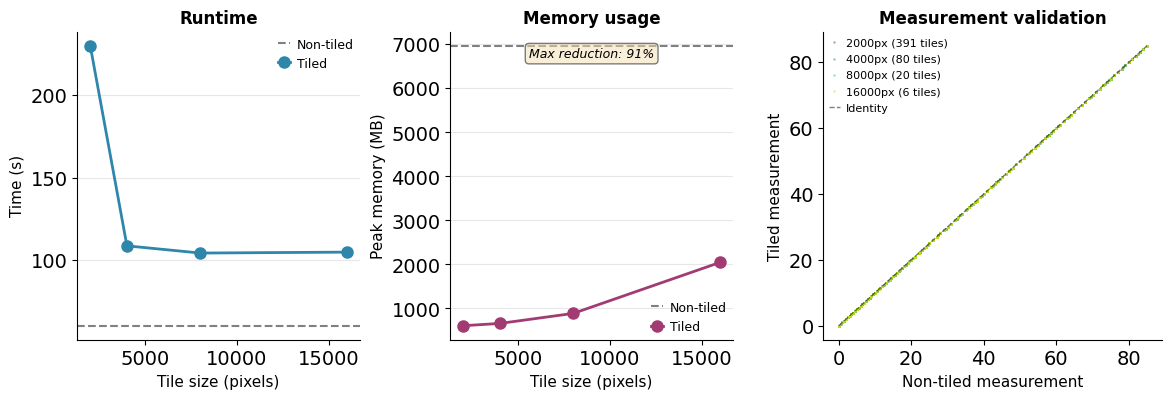

In [9]:
# Create and display plots
fig = plot_benchmark_results(
    results,
    save_path='figures/benchmark_tiling.pdf')
plt.show()